# Getting started with `chem`

Sanity check that the `chem` kernel and package are wired up correctly.

In [1]:
import chem

chem.__version__

'0.1.0'

## ChEMBL activities for BRAF (UniProt entry name lookup)

`chem.chembl.download_activities` accepts a ChEMBL target id, a UniProt
accession, or a UniProt entry name (mnemonic) such as `BRAF_HUMAN` — it
resolves the id, calls the ChEMBL REST API directly (no
`chembl_webresource_client`), keeps only records with a pChEMBL value,
filters by molecular weight, and (when `normalize_smiles=True`) standardizes
each compound via the ChEMBL Structure Pipeline and aggregates duplicate
compounds into count/mean/median/std.

In [21]:
from chem import chembl

n = chembl.download_activities(
    "BRAF_HUMAN",
    mw=[250, 650],
    normalize_smiles=True,
    output="braf_activities.tsv",
)
n

download_activities(id='BRAF_HUMAN', mw=[250, 650], normalize_smiles=True, output='braf_activities.tsv')
fetching activities for CHEMBL5145: 100%|██████████████████████████████████████████████████████████████| 9836/9836 [01:49<00:00, 89.66rec/s]
wrote 5623 rows to braf_activities.tsv


5623

### Preview the result

In [3]:
import pandas as pd

df = pd.read_csv("braf_activities.tsv", sep="\t")
print(df.size)
df.sort_values("pchembl_mean", ascending=False).head(10)

KeyboardInterrupt: 

### Draw the most potent compound

CHEMBL5885861 pchembl_mean= 10.7 n= 2


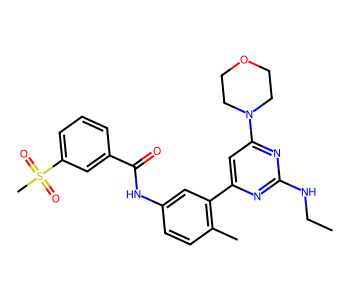

In [4]:
from rdkit import Chem
from rdkit.Chem.Draw import MolToImage

top = df.sort_values("pchembl_mean", ascending=False).iloc[0]
mol = Chem.MolFromSmiles(top["smiles"])
print(top["parent_chembl_id"], "pchembl_mean=", top["pchembl_mean"], "n=", top["n"])
MolToImage(mol, size=(350, 300))

## RCSB PDB structures for thrombin (UniProt entry name lookup)

`chem.rcsb.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` (ChEMBL target id, UniProt accession, or
UniProt entry name). It resolves the id to a UniProt accession, finds every
PDB entry annotated with that accession via the RCSB Search API, optionally
filters by resolution (entries without one, e.g. NMR structures, are dropped
whenever a threshold is given), and downloads each entry's structure file(s).
Files already present in `outdir` are left alone, so re-running only fetches
what's missing.

In [22]:
from chem import rcsb

n = rcsb.download_structures(
    "THRB_HUMAN",
    resolution_thres=1.5,
    filetype="pdb",
    outdir="data",
)
n

download_structures(id='THRB_HUMAN', resolution_thres=1.5, outdir='data', filetype='pdb')


HTTPError: 502 Server Error: Bad Gateway for url: https://search.rcsb.org/rcsbsearch/v2/query

### View one of the downloaded structures

In [20]:
import os

import py3Dmol

pdb_files = sorted(f for f in os.listdir("data") if f.endswith(".pdb"))
print(len(pdb_files), "structures downloaded, e.g.", pdb_files[:254])

with open(os.path.join("data", pdb_files[0])) as f:
    view = py3Dmol.view(width=500, height=400)
    view.addModel(f.read(), "pdb")
    view.setStyle({"cartoon": {"color": "spectrum"}})
    view.zoomTo()
view.show()

254 structures downloaded, e.g. ['1A3B.pdb', '1A3E.pdb', '1A4W.pdb', '1AD8.pdb', '1AE8.pdb', '1AFE.pdb', '1AHT.pdb', '1AI8.pdb', '1AY6.pdb', '1BA8.pdb', '1BCU.pdb', '1C1U.pdb', '1C1V.pdb', '1C1W.pdb', '1C5L.pdb', '1C5N.pdb', '1C5O.pdb', '1D6W.pdb', '1DE7.pdb', '1DOJ.pdb', '1EB1.pdb', '1G30.pdb', '1G32.pdb', '1G37.pdb', '1GHV.pdb', '1GHW.pdb', '1GHX.pdb', '1GHY.pdb', '1GJ4.pdb', '1GJ5.pdb', '1H8D.pdb', '1H8I.pdb', '1HAG.pdb', '1HBT.pdb', '1IHS.pdb', '1JOU.pdb', '1K21.pdb', '1K22.pdb', '1LHC.pdb', '1MU6.pdb', '1MU8.pdb', '1MUE.pdb', '1NM6.pdb', '1NO9.pdb', '1NT1.pdb', '1O2G.pdb', '1O5G.pdb', '1OYT.pdb', '1PPB.pdb', '1QBV.pdb', '1QJ1.pdb', '1QUR.pdb', '1SB1.pdb', '1SFQ.pdb', '1SHH.pdb', '1SL3.pdb', '1T4U.pdb', '1T4V.pdb', '1TA6.pdb', '1TOM.pdb', '1UMA.pdb', '1VR1.pdb', '1VZQ.pdb', '1W7G.pdb', '1XMN.pdb', '1YPE.pdb', '1YPG.pdb', '1YPJ.pdb', '1YPK.pdb', '1YPL.pdb', '1YPM.pdb', '1Z71.pdb', '1Z8I.pdb', '1Z8J.pdb', '1ZRB.pdb', '2A0Q.pdb', '2AFQ.pdb', '2BDY.pdb', '2BVR.pdb', '2BVS.pdb', '2BXT.p

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

## AlphaFold DB predicted structure for thrombin (UniProt entry name lookup)

`chem.alphafold.download_structures` accepts the same three id forms as
`chem.chembl.download_activities` and `chem.rcsb.download_structures`. It
resolves the id to a UniProt accession and downloads every AlphaFold DB
prediction entry for it (usually one, but very large proteins may be split
into fragments, and some targets without an official prediction have
community-submitted alternatives instead), optionally filtered by a minimum
average pLDDT confidence (`plddt_thres`, 0-100). As with `chem.rcsb`, files
already present in `outdir` are left alone.

In [1]:
from chem import alphafold

n = alphafold.download_structures(
    "THRB_HUMAN",
    outdir="af_data",
    filetype="pdb",
)
n

download_structures(id='THRB_HUMAN', plddt_thres=None, outdir='af_data', filetype='pdb')


downloading structures to af_data:   0%|          | 0/1 [00:00<?, ?entry/s]

downloading structures to af_data: 100%|██████████| 1/1 [00:00<00:00,  8.36entry/s]

downloading structures to af_data: 100%|██████████| 1/1 [00:00<00:00,  8.29entry/s]


wrote 1 structures to af_data


1

### View the predicted structure, colored by pLDDT confidence

In [2]:
import os

import py3Dmol

pdb_files = sorted(f for f in os.listdir("af_data") if f.endswith(".pdb"))
print(pdb_files)

with open(os.path.join("af_data", pdb_files[0])) as f:
    view = py3Dmol.view(width=500, height=400)
    view.addModel(f.read(), "pdb")
    # AlphaFold stores per-residue pLDDT confidence in the B-factor column.
    view.setStyle({"cartoon": {"colorscheme": {"prop": "b", "gradient": "roygb", "min": 50, "max": 90}}})
    view.zoomTo()
view.show()

['AF-P00734-F1.pdb']


3Dmol.js failed to load for some reason. Please check your browser console for error messages.